# Logistic Regresson pada Binary Classification Task

Linear Regression
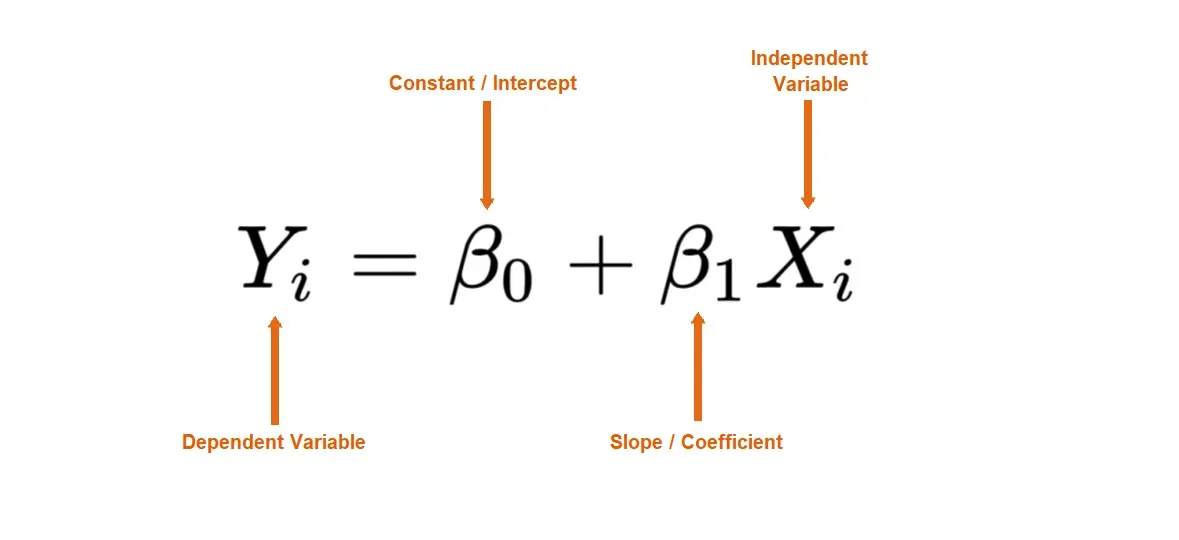

Multiple Linear Regression
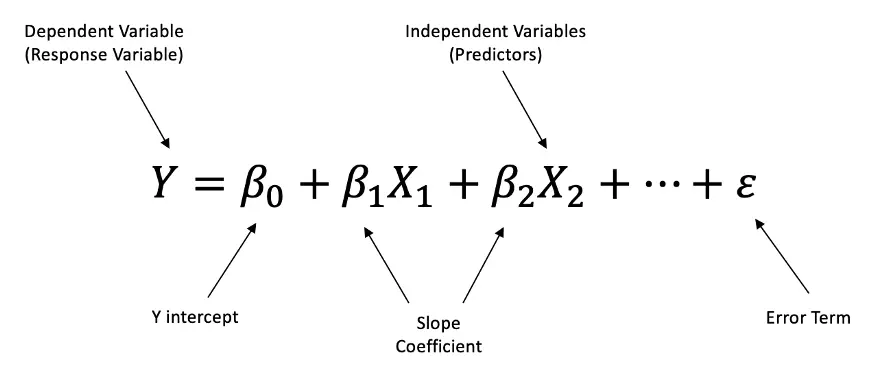

Logistic Regression

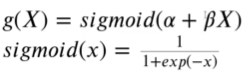
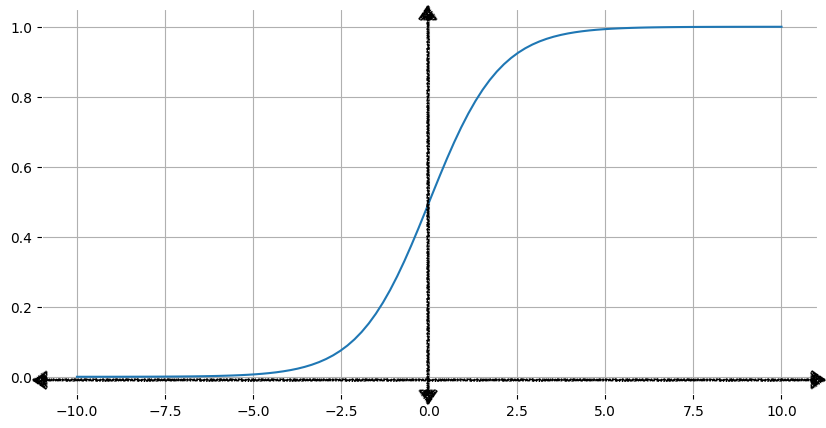
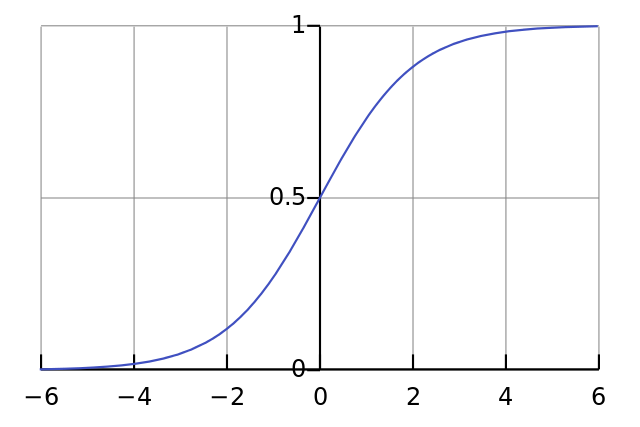

# Dataset: SMS Spam Collection Dataset

In [2]:
import pandas as pd

df = pd.read_csv('./dataset/SMSSpamCollection',
sep='\t',
header=None,
names=['label', 'sms'])

df.head()

,label,sms
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

# Training & Testing Dataset

In [4]:
from sklearn.preprocessing import LabelBinarizer

X = df['sms'].values
y = df['label'].values

lb = LabelBinarizer()
y = lb.fit_transform(y).ravel()
lb.classes_

array(['ham', 'spam'], dtype='<U4')

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25, random_state=42)

print(X_train, '\n')
print(y_train)

['WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.'
 "So how's scotland. Hope you are not over showing your JJC tendencies. Take care. Live the dream"
 'when you and derek done with class?' ...
 "Prabha..i'm soryda..realy..frm heart i'm sory"
 'Nt joking seriously i told' 'Did he just say somebody is named tampa'] 

[1 0 0 ... 0 0 0]


## Feature Extraction dengan TF-IDF

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 55879 stored elements and shape (4179, 7490)>
  Coords	Values
  (0, 7277)	0.21751656143810313
  (0, 1046)	0.14830270818246086
  (0, 7003)	0.2253470838055343
  (0, 4582)	0.19868987802008994
  (0, 2051)	0.18108062992459156
  (0, 7453)	0.07296508854525732
  (0, 3230)	0.10882678981142477
  (0, 1244)	0.1543329365001276
  (0, 5803)	0.19868987802008994
  (0, 6690)	0.141539967341859
  (0, 5446)	0.2807001863760787
  (0, 698)	0.2450282891750925
  (0, 5243)	0.1742914275865926
  (0, 5586)	0.25094826285330657
  (0, 1757)	0.3260359616382076
  (0, 1549)	0.10746868453913862
  (0, 193)	0.2807001863760787
  (0, 1814)	0.20435112554756152
  (0, 3804)	0.2807001863760787
  (0, 6999)	0.20760083145563224
  (0, 268)	0.228441801542862
  (0, 3376)	0.20760083145563224
  (0, 4771)	0.13923802451667316
  (1, 7453)	0.09615771392941105
  (1, 6079)	0.1538357656395538
  :	:
  (4174, 7328)	0.32340373637003494
  (4174, 2425)	0.37315911837617616
  (4174, 7312)	0

# Binary Classification dengan Logistic Regression

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model = model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

for pred, sms in zip(y_pred[:5], X_test[:5]):
    print(f'PRED: {pred} - SMS: {sms}\n')

PRED: 0 - SMS: Squeeeeeze!! This is christmas hug.. If u lik my frndshp den hug me back.. If u get 3 u r cute:) 6 u r luvd:* 9 u r so lucky;) None? People hate u:

PRED: 0 - SMS: And also I've sorta blown him off a couple times recently so id rather not text him out of the blue looking for weed

PRED: 0 - SMS: Mmm thats better now i got a roast down me! id b better if i had a few drinks down me 2! Good indian?

PRED: 0 - SMS: Mm have some kanji dont eat anything heavy ok

PRED: 0 - SMS: So there's a ring that comes with the guys costumes. It's there so they can gift their future yowifes. Hint hint



# Evaluation Mrtrics pada Binary Classification


1. Confusion Matrix

2. Accuracy

3. Precission & Recall

4. F1 Score

5. ROC

## Confusion Matrix

Confusion Matrix seringkali juga dikenal sebagai error matrix

In [8]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(y_test, y_pred)
matrix

array([[1207,    0],
       [  38,  148]])

In [9]:
tn, fp, fn, tp = matrix.ravel()

print(f'True Negative : {tn}')
print(f'False Positive : {fp}')
print(f'False Negative : {fn}')
print(f'True Positive : {tp}')


True Negative : 1207
False Positive : 0
False Negative : 38
True Positive : 148


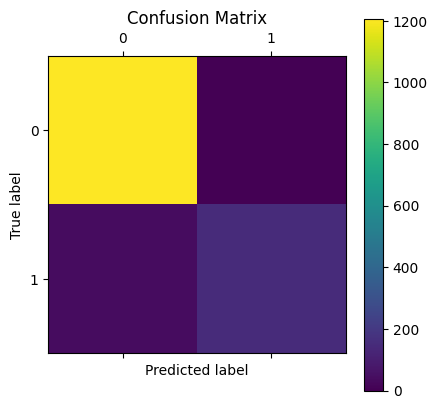

In [10]:
import matplotlib.pyplot as plt

plt.matshow(matrix)
plt.colorbar()

plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

## Accuracy

Accuracy mengukur porsi dari hasil prediksi yang tepat

In [11]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9727207465900933

## Precision & Recall

### Precision or Positive Predictive Value (PPV)


In [12]:
from sklearn.metrics import precision_score

precision_score(y_test, y_pred)

1.0

### Recall or True Positive Rate (TPR) or Senssitivity

In [13]:
from sklearn.metrics import recall_score

recall_score(y_test, y_pred)

0.7956989247311828

## F1-Score 

F1-Score atau F1-measure adalah harmonic mean dari precision dan recall

In [14]:
from sklearn.metrics import f1_score

f1_score(y_test, y_pred)

0.8862275449101796

## ROC: Reciever Operating Charactiristic

ROC menawarkan visual terhadap performa dari classifier dengan membandingkan nilai Recal (TPR) dan nilai Fallout (FRP)

fallout = FP / (TN + FP)

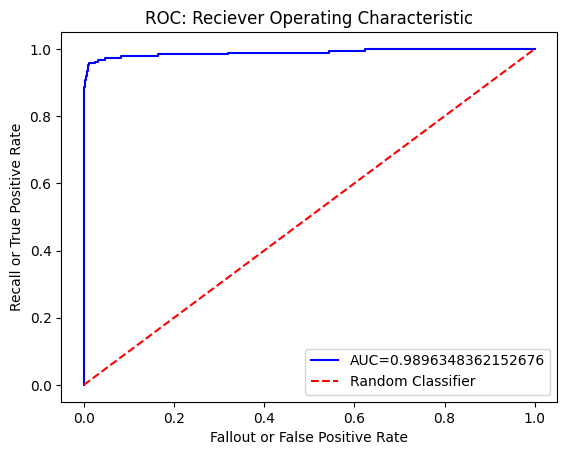

In [15]:
from sklearn.metrics import roc_curve, auc

prob_estimates = model.predict_proba(X_test_tfidf)

fpr, tpr, threshold = roc_curve(y_test, prob_estimates[:, 1])
nilai_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, 'b', label=f'AUC={nilai_auc}')
plt.plot([0,1], [0,1], 'r--', label='Random Classifier')

plt.title('ROC: Reciever Operating Characteristic')
plt.xlabel('Fallout or False Positive Rate')
plt.ylabel('Recall or True Positive Rate')
plt.legend()
plt.show()